## 04 — Baseline Modeling

This notebook starts from the final model-ready dataset created in `03_data_cleaning_preprocessing.ipynb`.

Main goals:
- Load the supervised feature table.
- Create strict time-based train/validation/calibration/test splits.
- Establish a deterministic baseline first.
- Then move toward XGBoost point forecasts, quantile forecasts, and conformal calibration.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = ROOT / "data_processed"
RESULTS_DIR = ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Processed data folder:", DATA_PROCESSED)
print("Results folder:", RESULTS_DIR)

Project root: e:\D\Research Work FAST Thesis\pv-thesis
Processed data folder: e:\D\Research Work FAST Thesis\pv-thesis\data_processed
Results folder: e:\D\Research Work FAST Thesis\pv-thesis\results


In [2]:
model_features_path = DATA_PROCESSED / "df_model_features_v1.pkl"

if not model_features_path.exists():
    raise FileNotFoundError(f"Could not find: {model_features_path}")

df = pd.read_pickle(model_features_path)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Loaded model-ready dataset.")
print("Shape:", df.shape)
print("Timestamp range:", df["timestamp"].min(), "to", df["timestamp"].max())
print("Any missing values?", df.isna().any().any())

display(df.head())
display(df.tail())

Loaded model-ready dataset.
Shape: (55151, 18)
Timestamp range: 2009-01-17 07:00:00 to 2023-09-30 17:00:00
Any missing values? False


,timestamp,y_active_power,hour,day_of_year,month,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,Active_Power_lag_1h,Active_Power_lag_2h,Active_Power_lag_3h,Active_Power_lag_24h,Global_Horizontal_Radiation_lag_1h,Diffuse_Horizontal_Radiation_lag_1h,Weather_Temperature_Celsius_lag_1h,Weather_Relative_Humidity_lag_1h,Weather_Daily_Rainfall_lag_1h
0,2009-01-17 07:00:00,0.649817,7,17,1,0.965926,-0.258819,0.288291,0.957543,0.111353,0.000000,0.000000,0.574844,41.832089,36.955103,25.843725,27.964213,0.0
1,2009-01-17 08:00:00,1.891664,8,17,1,0.866025,-0.500000,0.288291,0.957543,0.649817,0.111353,0.000000,1.953644,229.742687,105.933195,27.269521,23.738529,0.0
2,2009-01-17 09:00:00,2.949394,9,17,1,0.707107,-0.707107,0.288291,0.957543,1.891664,0.649817,0.111353,3.049669,481.603076,128.305213,29.523337,18.827057,0.0
3,2009-01-17 10:00:00,3.712172,10,17,1,0.500000,-0.866025,0.288291,0.957543,2.949394,1.891664,0.649817,3.777403,703.295298,139.420567,31.009439,17.933351,0.0
4,2009-01-17 11:00:00,3.912083,11,17,1,0.258819,-0.965926,0.288291,0.957543,3.712172,2.949394,1.891664,4.201639,892.906784,164.725136,32.449679,19.507836,0.0


,timestamp,y_active_power,hour,day_of_year,month,hour_sin,hour_cos,dayofyear_sin,dayofyear_cos,Active_Power_lag_1h,Active_Power_lag_2h,Active_Power_lag_3h,Active_Power_lag_24h,Global_Horizontal_Radiation_lag_1h,Diffuse_Horizontal_Radiation_lag_1h,Weather_Temperature_Celsius_lag_1h,Weather_Relative_Humidity_lag_1h,Weather_Daily_Rainfall_lag_1h
55146,2023-09-30 13:00:00,2.060100,13,273,9,-0.258819,-0.965926,-0.99987,-0.016127,4.029142,3.773189,3.447264,3.817536,1164.952815,219.863467,35.387192,9.459170,0.0
55147,2023-09-30 14:00:00,2.239317,14,273,9,-0.500000,-0.866025,-0.99987,-0.016127,2.060100,4.029142,3.773189,2.083508,575.120794,274.384832,34.415135,9.767379,0.0
55148,2023-09-30 15:00:00,2.603722,15,273,9,-0.707107,-0.707107,-0.99987,-0.016127,2.239317,2.060100,4.029142,3.069422,561.257732,260.735093,34.809876,9.494566,0.0
55149,2023-09-30 16:00:00,1.055781,16,273,9,-0.866025,-0.500000,-0.99987,-0.016127,2.603722,2.239317,2.060100,1.800900,637.263162,170.684111,35.150859,9.187579,0.0
55150,2023-09-30 17:00:00,0.457261,17,273,9,-0.965926,-0.258819,-0.99987,-0.016127,1.055781,2.603722,2.239317,0.567483,273.522446,120.577508,34.555827,9.302099,0.0


In [3]:
#Define target and feature columns

target_col = "y_active_power"

feature_cols = [
    c for c in df.columns
    if c not in ["timestamp", target_col]
]

print("Target column:", target_col)
print("Number of features:", len(feature_cols))
print("Feature columns:")

for col in feature_cols:
    print("-", col)

X = df[feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

Target column: y_active_power
Number of features: 16
Feature columns:
- hour
- day_of_year
- month
- hour_sin
- hour_cos
- dayofyear_sin
- dayofyear_cos
- Active_Power_lag_1h
- Active_Power_lag_2h
- Active_Power_lag_3h
- Active_Power_lag_24h
- Global_Horizontal_Radiation_lag_1h
- Diffuse_Horizontal_Radiation_lag_1h
- Weather_Temperature_Celsius_lag_1h
- Weather_Relative_Humidity_lag_1h
- Weather_Daily_Rainfall_lag_1h
X shape: (55151, 16)
y shape: (55151,)


,y_active_power
count,55151.000000
mean,2.425479
std,1.365492
min,0.008028
25%,1.190458
50%,2.688939
75%,3.681503
max,5.106039


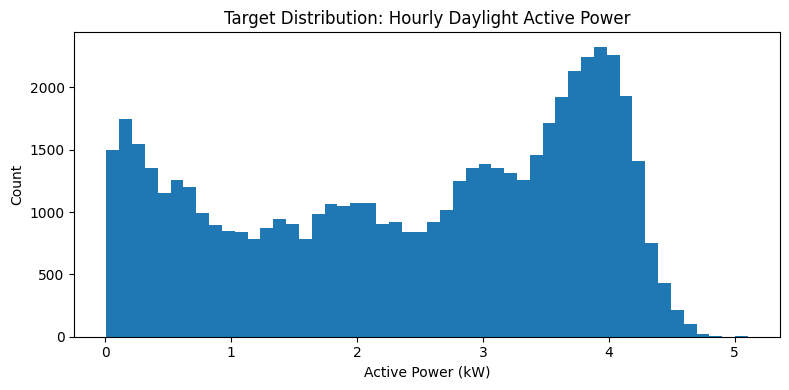

In [15]:
#Quick target distribution check

target_summary = df[target_col].describe().to_frame(name=target_col)

display(target_summary)

plt.figure(figsize=(8, 4))
plt.hist(df[target_col], bins=50)
plt.title("Target Distribution: Hourly Daylight Active Power")
plt.xlabel("Active Power (kW)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "target_distribution.png", dpi=150)
plt.show()

In [5]:
#Define time-based split

#Train: 2009–2019
#Validation: 2020
#Calibration: 2021
#Test: 2022–2023-09

split_dates = {
    "train_start": "2009-01-01",
    "train_end": "2019-12-31 23:59:59",
    "val_start": "2020-01-01",
    "val_end": "2020-12-31 23:59:59",
    "cal_start": "2021-01-01",
    "cal_end": "2021-12-31 23:59:59",
    "test_start": "2022-01-01",
    "test_end": "2023-09-30 23:59:59",
}

train_mask = df["timestamp"].between(split_dates["train_start"], split_dates["train_end"])
val_mask = df["timestamp"].between(split_dates["val_start"], split_dates["val_end"])
cal_mask = df["timestamp"].between(split_dates["cal_start"], split_dates["cal_end"])
test_mask = df["timestamp"].between(split_dates["test_start"], split_dates["test_end"])

df_train = df.loc[train_mask].copy()
df_val = df.loc[val_mask].copy()
df_cal = df.loc[cal_mask].copy()
df_test = df.loc[test_mask].copy()

split_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(df_train),
        "start": df_train["timestamp"].min(),
        "end": df_train["timestamp"].max(),
    },
    {
        "split": "validation",
        "rows": len(df_val),
        "start": df_val["timestamp"].min(),
        "end": df_val["timestamp"].max(),
    },
    {
        "split": "calibration",
        "rows": len(df_cal),
        "start": df_cal["timestamp"].min(),
        "end": df_cal["timestamp"].max(),
    },
    {
        "split": "test",
        "rows": len(df_test),
        "start": df_test["timestamp"].min(),
        "end": df_test["timestamp"].max(),
    },
])

display(split_summary)
print("Total split rows:", split_summary["rows"].sum())
print("Original rows:", len(df))

,split,rows,start,end
0,train,40978,2009-01-17 07:00:00,2019-12-31 18:00:00
1,validation,3869,2020-01-01 06:00:00,2020-12-31 18:00:00
2,calibration,3798,2021-01-01 06:00:00,2021-12-31 17:00:00
3,test,6506,2022-01-01 06:00:00,2023-09-30 17:00:00


Total split rows: 55151
Original rows: 55151


In [6]:
#Create X/y arrays for each split

X_train = df_train[feature_cols].copy()
y_train = df_train[target_col].copy()

X_val = df_val[feature_cols].copy()
y_val = df_val[target_col].copy()

X_cal = df_cal[feature_cols].copy()
y_cal = df_cal[target_col].copy()

X_test = df_test[feature_cols].copy()
y_test = df_test[target_col].copy()

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_cal:", X_cal.shape, "y_cal:", y_cal.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (40978, 16) y_train: (40978,)
X_val: (3869, 16) y_val: (3869,)
X_cal: (3798, 16) y_cal: (3798,)
X_test: (6506, 16) y_test: (6506,)


In [7]:
#Save split datasets

split_dir = DATA_PROCESSED / "model_splits_v1"
split_dir.mkdir(parents=True, exist_ok=True)

df_train.to_pickle(split_dir / "train.pkl")
df_val.to_pickle(split_dir / "validation.pkl")
df_cal.to_pickle(split_dir / "calibration.pkl")
df_test.to_pickle(split_dir / "test.pkl")

split_summary.to_csv(split_dir / "split_summary.csv", index=False)

print("Saved split datasets to:", split_dir)

Saved split datasets to: e:\D\Research Work FAST Thesis\pv-thesis\data_processed\model_splits_v1


### 02 — Persistence baseline

This baseline predicts the current daylight-hour PV power using the previous hour's PV power:

`y_hat(t) = Active_Power_lag_1h`

It is used as a simple benchmark before training XGBoost.

In [8]:
#Define metric helper

def regression_metrics(y_true, y_pred, model_name, split_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "model": model_name,
        "split": split_name,
        "rows": len(y_true),
        "MAE_kW": round(mae, 4),
        "RMSE_kW": round(rmse, 4),
        "MAE_pct_capacity": round(mae / 5.25 * 100, 2),
        "RMSE_pct_capacity": round(rmse / 5.25 * 100, 2),
    }

In [9]:
#Persistence predictions

persistence_feature = "Active_Power_lag_1h"

if persistence_feature not in feature_cols:
    raise ValueError(f"Missing feature: {persistence_feature}")

persistence_results = []

for split_name, X_split, y_split in [
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("calibration", X_cal, y_cal),
    ("test", X_test, y_test),
]:
    y_pred_persistence = X_split[persistence_feature]

    persistence_results.append(
        regression_metrics(
            y_true=y_split,
            y_pred=y_pred_persistence,
            model_name="persistence_lag_1h",
            split_name=split_name
        )
    )

persistence_metrics = pd.DataFrame(persistence_results)

display(persistence_metrics)

,model,split,rows,MAE_kW,RMSE_kW,MAE_pct_capacity,RMSE_pct_capacity
0,persistence_lag_1h,train,40978,0.6968,0.8396,13.27,15.99
1,persistence_lag_1h,validation,3869,0.6805,0.8219,12.96,15.65
2,persistence_lag_1h,calibration,3798,0.6778,0.8318,12.91,15.84
3,persistence_lag_1h,test,6506,0.6632,0.8127,12.63,15.48


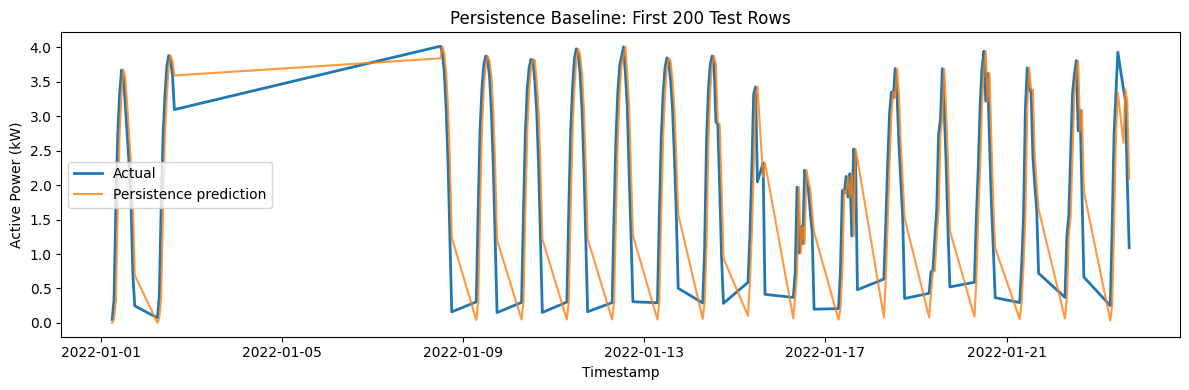

In [14]:
#Plot persistence baseline on test set

test_plot = df_test[["timestamp", target_col, "Active_Power_lag_1h"]].copy()
test_plot = test_plot.rename(columns={
    target_col: "actual",
    "Active_Power_lag_1h": "persistence_prediction"
})

plot_sample = test_plot.head(200)

plt.figure(figsize=(12, 4))
plt.plot(plot_sample["timestamp"], plot_sample["actual"], label="Actual", linewidth=2)
plt.plot(plot_sample["timestamp"], plot_sample["persistence_prediction"], label="Persistence prediction", alpha=0.8)
plt.title("Persistence Baseline: First 200 Test Rows")
plt.xlabel("Timestamp")
plt.ylabel("Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "persistence_baseline_test.png", dpi=150)
plt.show()

In [11]:
#Save persistence metrics

baseline_results_dir = RESULTS_DIR / "baseline_modeling"
baseline_results_dir.mkdir(parents=True, exist_ok=True)

persistence_metrics_path = baseline_results_dir / "persistence_metrics.csv"

persistence_metrics.to_csv(persistence_metrics_path, index=False)

print("Saved persistence metrics to:", persistence_metrics_path)

Saved persistence metrics to: e:\D\Research Work FAST Thesis\pv-thesis\results\baseline_modeling\persistence_metrics.csv


### 03 — XGBoost point forecast baseline

This stage trains a standard XGBoost regression model for point forecasting.

The goal is to check whether a learned ML model can beat the simple persistence baseline before moving to quantile forecasting and conformal calibration.

In [16]:
#Import and check XGBoost

import xgboost as xgb

print("xgboost version:", xgb.__version__)

xgboost version: 3.2.0


In [17]:
#Train standard XGBoost point model

xgb_point_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_point_model.fit(X_train, y_train)

print("XGBoost point model trained.")

XGBoost point model trained.


In [18]:
#Predict and physically clip predictions

#PV power cannot be negative and should not exceed the approximate system capacity.

RATED_CAPACITY_KW = 5.25

def predict_and_clip(model, X):
    y_pred_raw = model.predict(X)
    y_pred_clipped = np.clip(y_pred_raw, 0, RATED_CAPACITY_KW)
    return y_pred_raw, y_pred_clipped


xgb_predictions = {}

for split_name, X_split in [
    ("train", X_train),
    ("validation", X_val),
    ("calibration", X_cal),
    ("test", X_test),
]:
    y_pred_raw, y_pred_clipped = predict_and_clip(xgb_point_model, X_split)

    xgb_predictions[split_name] = {
        "raw": y_pred_raw,
        "clipped": y_pred_clipped
    }

    print(split_name)
    print("  raw min/max:", round(y_pred_raw.min(), 4), round(y_pred_raw.max(), 4))
    print("  clipped min/max:", round(y_pred_clipped.min(), 4), round(y_pred_clipped.max(), 4))

train
  raw min/max: 0.0337 4.8464
  clipped min/max: 0.0337 4.8464
validation
  raw min/max: 0.0281 4.5577
  clipped min/max: 0.0281 4.5577
calibration
  raw min/max: 0.0209 4.6606
  clipped min/max: 0.0209 4.6606
test
  raw min/max: 0.0094 4.4801
  clipped min/max: 0.0094 4.4801


In [19]:
#Evaluate XGBoost point forecast

xgb_point_results = []

for split_name, y_split in [
    ("train", y_train),
    ("validation", y_val),
    ("calibration", y_cal),
    ("test", y_test),
]:
    y_pred = xgb_predictions[split_name]["clipped"]

    xgb_point_results.append(
        regression_metrics(
            y_true=y_split,
            y_pred=y_pred,
            model_name="xgboost_point",
            split_name=split_name
        )
    )

xgb_point_metrics = pd.DataFrame(xgb_point_results)

display(xgb_point_metrics)

,model,split,rows,MAE_kW,RMSE_kW,MAE_pct_capacity,RMSE_pct_capacity
0,xgboost_point,train,40978,0.1654,0.2858,3.15,5.44
1,xgboost_point,validation,3869,0.1472,0.2683,2.80,5.11
2,xgboost_point,calibration,3798,0.1664,0.2866,3.17,5.46
3,xgboost_point,test,6506,0.1781,0.2948,3.39,5.61


In [20]:
#Compare persistence vs XGBoost

point_model_comparison = pd.concat(
    [persistence_metrics, xgb_point_metrics],
    ignore_index=True
)

display(point_model_comparison.sort_values(["split", "model"]))

,model,split,rows,MAE_kW,RMSE_kW,MAE_pct_capacity,RMSE_pct_capacity
2,persistence_lag_1h,calibration,3798,0.6778,0.8318,12.91,15.84
6,xgboost_point,calibration,3798,0.1664,0.2866,3.17,5.46
3,persistence_lag_1h,test,6506,0.6632,0.8127,12.63,15.48
7,xgboost_point,test,6506,0.1781,0.2948,3.39,5.61
0,persistence_lag_1h,train,40978,0.6968,0.8396,13.27,15.99
4,xgboost_point,train,40978,0.1654,0.2858,3.15,5.44
1,persistence_lag_1h,validation,3869,0.6805,0.8219,12.96,15.65
5,xgboost_point,validation,3869,0.1472,0.2683,2.80,5.11


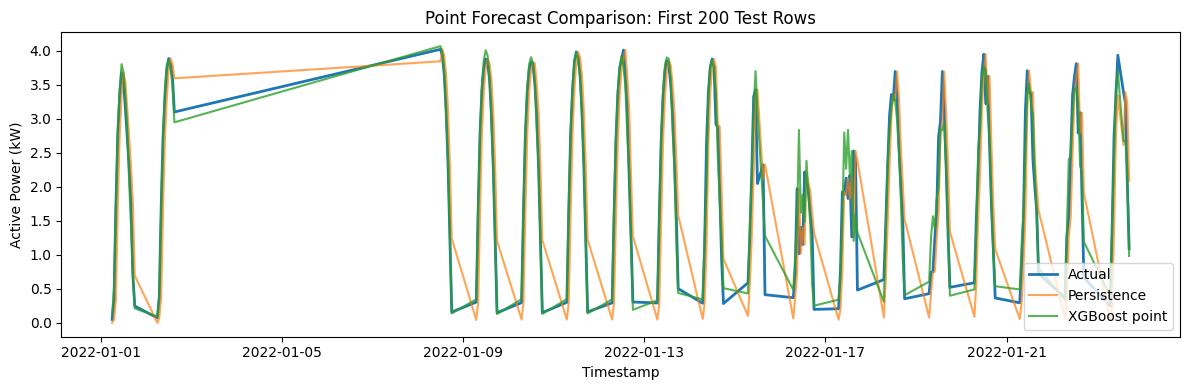

In [21]:
#Plot XGBoost vs persistence on test set

test_plot = df_test[["timestamp", target_col, "Active_Power_lag_1h"]].copy()

test_plot["xgboost_point_prediction"] = xgb_predictions["test"]["clipped"]

test_plot = test_plot.rename(columns={
    target_col: "actual",
    "Active_Power_lag_1h": "persistence_prediction"
})

plot_sample = test_plot.head(200)

plt.figure(figsize=(12, 4))
plt.plot(plot_sample["timestamp"], plot_sample["actual"], label="Actual", linewidth=2)
plt.plot(plot_sample["timestamp"], plot_sample["persistence_prediction"], label="Persistence", alpha=0.7)
plt.plot(plot_sample["timestamp"], plot_sample["xgboost_point_prediction"], label="XGBoost point", alpha=0.8)
plt.title("Point Forecast Comparison: First 200 Test Rows")
plt.xlabel("Timestamp")
plt.ylabel("Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "xgboost_point_vs_persistence_test.png", dpi=150)
plt.show()

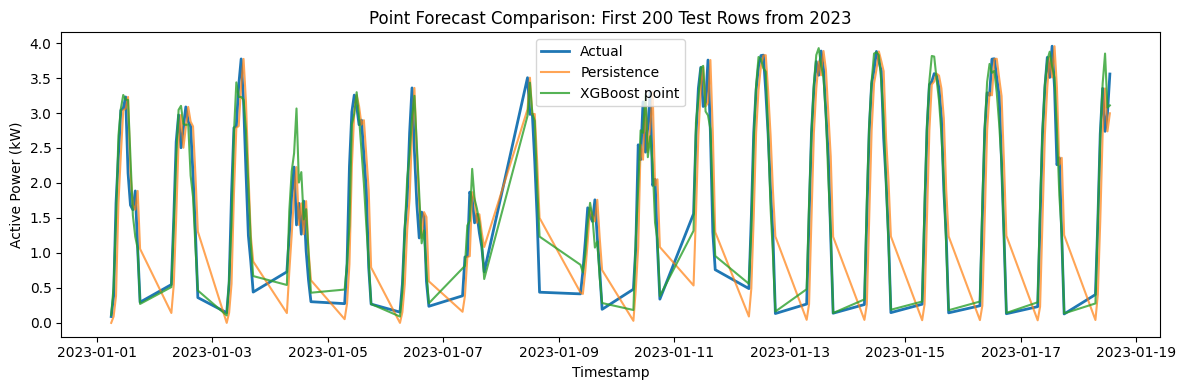

In [23]:
plot_sample_2023 = test_plot[
    test_plot["timestamp"] >= "2023-01-01"
].head(200)

plt.figure(figsize=(12, 4))
plt.plot(plot_sample_2023["timestamp"], plot_sample_2023["actual"], label="Actual", linewidth=2)
plt.plot(plot_sample_2023["timestamp"], plot_sample_2023["persistence_prediction"], label="Persistence", alpha=0.7)
plt.plot(plot_sample_2023["timestamp"], plot_sample_2023["xgboost_point_prediction"], label="XGBoost point", alpha=0.8)
plt.title("Point Forecast Comparison: First 200 Test Rows from 2023")
plt.xlabel("Timestamp")
plt.ylabel("Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "xgboost_point_vs_persistence_test_2023_sample.png", dpi=150)
plt.show()

In [24]:
#Calculate improvement over persistence

test_persistence_mae = persistence_metrics.loc[
    (persistence_metrics["split"] == "test"),
    "MAE_kW"
].iloc[0]

test_persistence_rmse = persistence_metrics.loc[
    (persistence_metrics["split"] == "test"),
    "RMSE_kW"
].iloc[0]

test_xgb_mae = xgb_point_metrics.loc[
    (xgb_point_metrics["split"] == "test"),
    "MAE_kW"
].iloc[0]

test_xgb_rmse = xgb_point_metrics.loc[
    (xgb_point_metrics["split"] == "test"),
    "RMSE_kW"
].iloc[0]

improvement_summary = pd.DataFrame([{
    "baseline_model": "persistence_lag_1h",
    "ml_model": "xgboost_point",
    "test_MAE_baseline": test_persistence_mae,
    "test_MAE_xgboost": test_xgb_mae,
    "MAE_reduction_pct": round((test_persistence_mae - test_xgb_mae) / test_persistence_mae * 100, 2),
    "test_RMSE_baseline": test_persistence_rmse,
    "test_RMSE_xgboost": test_xgb_rmse,
    "RMSE_reduction_pct": round((test_persistence_rmse - test_xgb_rmse) / test_persistence_rmse * 100, 2)
}])

display(improvement_summary)

,baseline_model,ml_model,test_MAE_baseline,test_MAE_xgboost,MAE_reduction_pct,test_RMSE_baseline,test_RMSE_xgboost,RMSE_reduction_pct
0,persistence_lag_1h,xgboost_point,0.6632,0.1781,73.15,0.8127,0.2948,63.73


,feature,importance
4,hour_cos,0.710473
10,Active_Power_lag_24h,0.108708
7,Active_Power_lag_1h,0.074203
0,hour,0.041227
3,hour_sin,0.023547
11,Global_Horizontal_Radiation_lag_1h,0.022667
12,Diffuse_Horizontal_Radiation_lag_1h,0.005708
6,dayofyear_cos,0.002725
9,Active_Power_lag_3h,0.001969
8,Active_Power_lag_2h,0.001735


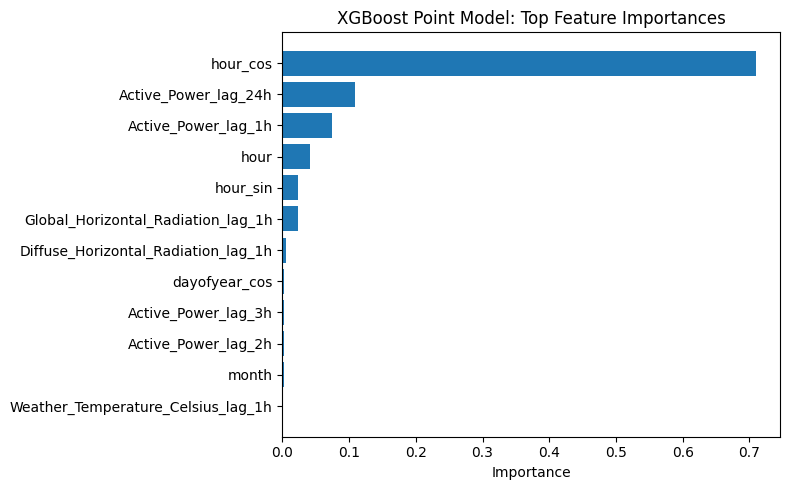

In [25]:
#Feature importance sanity check

#This helps verify that the model is relying on meaningful features such as lagged power, time-of-day, and irradiance/weather lags.

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_point_model.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"].head(12)[::-1], feature_importance["importance"].head(12)[::-1])
plt.title("XGBoost Point Model: Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "xgboost_point_feature_importance.png", dpi=150)
plt.show()

In [26]:
#Save XGBoost point results

xgb_point_metrics_path = baseline_results_dir / "xgboost_point_metrics.csv"
point_comparison_path = baseline_results_dir / "point_model_comparison.csv"
improvement_summary_path = baseline_results_dir / "xgboost_vs_persistence_improvement.csv"

xgb_point_metrics.to_csv(xgb_point_metrics_path, index=False)
point_model_comparison.to_csv(point_comparison_path, index=False)
improvement_summary.to_csv(improvement_summary_path, index=False)

print("Saved XGBoost point metrics:")
print(xgb_point_metrics_path)
print(point_comparison_path)
print(improvement_summary_path)

Saved XGBoost point metrics:
e:\D\Research Work FAST Thesis\pv-thesis\results\baseline_modeling\xgboost_point_metrics.csv
e:\D\Research Work FAST Thesis\pv-thesis\results\baseline_modeling\point_model_comparison.csv
e:\D\Research Work FAST Thesis\pv-thesis\results\baseline_modeling\xgboost_vs_persistence_improvement.csv


So we can now say:

The ML model has learned the PV forecasting problem well enough to justify moving from point forecasting to probabilistic forecasting.

The feature importance also looks logical. hour_cos being dominant is not a problem because PV output has a strong daily solar pattern. Then Active_Power_lag_24h, Active_Power_lag_1h, hour, and irradiance lag are also important, which is physically reasonable.

### 04 — XGBoost quantile forecasts: P10, P50, P90

This stage trains three XGBoost quantile models:
- P10 for the lower quantile,
- P50 for the median forecast,
- P90 for the upper quantile.

These raw quantile forecasts will later be used to form prediction intervals and then conformalized using the calibration set.

In [27]:
#Confirm quantile objective support

print("xgboost version:", xgb.__version__)

# Quick reminder of available split shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_cal:", X_cal.shape)
print("X_test:", X_test.shape)

xgboost version: 3.2.0
X_train: (40978, 16)
X_val: (3869, 16)
X_cal: (3798, 16)
X_test: (6506, 16)


In [28]:
#Define and train quantile models

quantile_levels = {
    "p10": 0.10,
    "p50": 0.50,
    "p90": 0.90
}

xgb_quantile_models = {}

for name, alpha in quantile_levels.items():
    print(f"Training XGBoost quantile model: {name} / alpha={alpha}")

    model = xgb.XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=alpha,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )

    model.fit(X_train, y_train)

    xgb_quantile_models[name] = model

print("All quantile models trained.")

Training XGBoost quantile model: p10 / alpha=0.1
Training XGBoost quantile model: p50 / alpha=0.5
Training XGBoost quantile model: p90 / alpha=0.9
All quantile models trained.


In [29]:
#Generate quantile predictions

RATED_CAPACITY_KW = 5.25

def predict_quantiles(models, X):
    predictions = {}

    for name, model in models.items():
        raw_pred = model.predict(X)
        clipped_pred = np.clip(raw_pred, 0, RATED_CAPACITY_KW)
        predictions[name] = clipped_pred

    return predictions


quantile_predictions = {}

for split_name, X_split in [
    ("train", X_train),
    ("validation", X_val),
    ("calibration", X_cal),
    ("test", X_test),
]:
    quantile_predictions[split_name] = predict_quantiles(
        xgb_quantile_models,
        X_split
    )

    print(split_name)
    for q_name in ["p10", "p50", "p90"]:
        q_pred = quantile_predictions[split_name][q_name]
        print(
            f"  {q_name}: min={q_pred.min():.4f}, "
            f"mean={q_pred.mean():.4f}, max={q_pred.max():.4f}"
        )

train
  p10: min=0.0000, mean=2.1688, max=4.5130
  p50: min=0.0332, mean=2.4703, max=4.8215
  p90: min=0.0412, mean=2.7303, max=5.0531
validation
  p10: min=0.0208, mean=2.1122, max=4.4155
  p50: min=0.0394, mean=2.3903, max=4.4969
  p90: min=0.0583, mean=2.6490, max=4.7466
calibration
  p10: min=0.0162, mean=2.1236, max=4.4469
  p50: min=0.0248, mean=2.3871, max=4.6622
  p90: min=0.0535, mean=2.6386, max=4.7817
test
  p10: min=0.0000, mean=2.0511, max=4.3692
  p50: min=0.0366, mean=2.3489, max=4.4632
  p90: min=0.0544, mean=2.6476, max=4.6290


In [30]:
#Create test quantile prediction table

test_quantile_predictions = df_test[["timestamp", target_col]].copy()

test_quantile_predictions = test_quantile_predictions.rename(
    columns={target_col: "actual"}
)

test_quantile_predictions["p10_raw"] = quantile_predictions["test"]["p10"]
test_quantile_predictions["p50_raw"] = quantile_predictions["test"]["p50"]
test_quantile_predictions["p90_raw"] = quantile_predictions["test"]["p90"]

display(test_quantile_predictions.head())
display(test_quantile_predictions.tail())

,timestamp,actual,p10_raw,p50_raw,p90_raw
48645,2022-01-01 06:00:00,0.050464,0.084264,0.140547,0.172138
48646,2022-01-01 07:00:00,0.334097,0.435753,0.500605,0.552183
48647,2022-01-01 08:00:00,1.733606,1.636702,1.748029,1.838541
48648,2022-01-01 09:00:00,2.756478,2.698221,2.780206,2.924938
48649,2022-01-01 10:00:00,3.342267,3.387340,3.461565,3.560797


,timestamp,actual,p10_raw,p50_raw,p90_raw
55146,2023-09-30 13:00:00,2.060100,2.722495,3.597242,3.986300
55147,2023-09-30 14:00:00,2.239317,1.213529,2.004221,3.114745
55148,2023-09-30 15:00:00,2.603722,1.191293,2.066064,2.791045
55149,2023-09-30 16:00:00,1.055781,1.138145,1.476505,2.025642
55150,2023-09-30 17:00:00,0.457261,0.346909,0.479340,0.627131


In [31]:
#Check quantile crossing

#A valid quantile forecast should usually satisfy P10 <= P50 <= P90

#Sometimes independently trained quantile models can cross. We need to check this before interval evaluation.

cross_p10_p50 = test_quantile_predictions["p10_raw"] > test_quantile_predictions["p50_raw"]
cross_p50_p90 = test_quantile_predictions["p50_raw"] > test_quantile_predictions["p90_raw"]
cross_p10_p90 = test_quantile_predictions["p10_raw"] > test_quantile_predictions["p90_raw"]

quantile_crossing_summary = pd.DataFrame([{
    "split": "test",
    "rows": len(test_quantile_predictions),
    "p10_greater_than_p50": int(cross_p10_p50.sum()),
    "p50_greater_than_p90": int(cross_p50_p90.sum()),
    "p10_greater_than_p90": int(cross_p10_p90.sum()),
    "p10_gt_p50_pct": round(cross_p10_p50.mean() * 100, 3),
    "p50_gt_p90_pct": round(cross_p50_p90.mean() * 100, 3),
    "p10_gt_p90_pct": round(cross_p10_p90.mean() * 100, 3)
}])

display(quantile_crossing_summary)

,split,rows,p10_greater_than_p50,p50_greater_than_p90,p10_greater_than_p90,p10_gt_p50_pct,p50_gt_p90_pct,p10_gt_p90_pct
0,test,6506,218,49,6,3.351,0.753,0.092


In [32]:
#Compare P50 quantile forecast against XGBoost point model

p50_test_metrics = pd.DataFrame([
    regression_metrics(
        y_true=y_test,
        y_pred=test_quantile_predictions["p50_raw"],
        model_name="xgboost_quantile_p50",
        split_name="test"
    )
])

point_vs_p50_test = pd.concat([
    xgb_point_metrics[xgb_point_metrics["split"] == "test"],
    p50_test_metrics
], ignore_index=True)

display(point_vs_p50_test)

,model,split,rows,MAE_kW,RMSE_kW,MAE_pct_capacity,RMSE_pct_capacity
0,xgboost_point,test,6506,0.1781,0.2948,3.39,5.61
1,xgboost_quantile_p50,test,6506,0.1738,0.3025,3.31,5.76


### 05 — Quantile forecast diagnostics and non-crossing correction

The P10, P50, and P90 quantile models were trained independently, so occasional quantile crossing can occur.

Before interval evaluation, this stage creates monotone quantile forecasts using row-wise sorting:

P10 <= P50 <= P90

No target values are used in this correction.

In [33]:
#Build raw and corrected quantile prediction tables

def make_quantile_table(split_df, split_name):
    table = split_df[["timestamp", target_col]].copy()
    table = table.rename(columns={target_col: "actual"})

    table["p10_raw"] = quantile_predictions[split_name]["p10"]
    table["p50_raw"] = quantile_predictions[split_name]["p50"]
    table["p90_raw"] = quantile_predictions[split_name]["p90"]

    raw_values = table[["p10_raw", "p50_raw", "p90_raw"]].to_numpy()
    sorted_values = np.sort(raw_values, axis=1)

    table["p10"] = sorted_values[:, 0]
    table["p50"] = sorted_values[:, 1]
    table["p90"] = sorted_values[:, 2]

    return table


quantile_tables = {
    "train": make_quantile_table(df_train, "train"),
    "validation": make_quantile_table(df_val, "validation"),
    "calibration": make_quantile_table(df_cal, "calibration"),
    "test": make_quantile_table(df_test, "test")
}

test_quantile_table = quantile_tables["test"]

display(test_quantile_table.head())
display(test_quantile_table.tail())

,timestamp,actual,p10_raw,p50_raw,p90_raw,p10,p50,p90
48645,2022-01-01 06:00:00,0.050464,0.084264,0.140547,0.172138,0.084264,0.140547,0.172138
48646,2022-01-01 07:00:00,0.334097,0.435753,0.500605,0.552183,0.435753,0.500605,0.552183
48647,2022-01-01 08:00:00,1.733606,1.636702,1.748029,1.838541,1.636702,1.748029,1.838541
48648,2022-01-01 09:00:00,2.756478,2.698221,2.780206,2.924938,2.698221,2.780206,2.924938
48649,2022-01-01 10:00:00,3.342267,3.387340,3.461565,3.560797,3.387340,3.461565,3.560797


,timestamp,actual,p10_raw,p50_raw,p90_raw,p10,p50,p90
55146,2023-09-30 13:00:00,2.060100,2.722495,3.597242,3.986300,2.722495,3.597242,3.986300
55147,2023-09-30 14:00:00,2.239317,1.213529,2.004221,3.114745,1.213529,2.004221,3.114745
55148,2023-09-30 15:00:00,2.603722,1.191293,2.066064,2.791045,1.191293,2.066064,2.791045
55149,2023-09-30 16:00:00,1.055781,1.138145,1.476505,2.025642,1.138145,1.476505,2.025642
55150,2023-09-30 17:00:00,0.457261,0.346909,0.479340,0.627131,0.346909,0.479340,0.627131


In [34]:
#Check quantile crossing before and after correction

def crossing_summary(table, split_name):
    raw_p10_gt_p50 = table["p10_raw"] > table["p50_raw"]
    raw_p50_gt_p90 = table["p50_raw"] > table["p90_raw"]
    raw_p10_gt_p90 = table["p10_raw"] > table["p90_raw"]
    raw_any_crossing = raw_p10_gt_p50 | raw_p50_gt_p90 | raw_p10_gt_p90

    fixed_p10_gt_p50 = table["p10"] > table["p50"]
    fixed_p50_gt_p90 = table["p50"] > table["p90"]
    fixed_p10_gt_p90 = table["p10"] > table["p90"]
    fixed_any_crossing = fixed_p10_gt_p50 | fixed_p50_gt_p90 | fixed_p10_gt_p90

    return {
        "split": split_name,
        "rows": len(table),
        "raw_any_crossing": int(raw_any_crossing.sum()),
        "raw_any_crossing_pct": round(raw_any_crossing.mean() * 100, 3),
        "raw_p10_gt_p50": int(raw_p10_gt_p50.sum()),
        "raw_p50_gt_p90": int(raw_p50_gt_p90.sum()),
        "raw_p10_gt_p90": int(raw_p10_gt_p90.sum()),
        "fixed_any_crossing": int(fixed_any_crossing.sum()),
        "fixed_any_crossing_pct": round(fixed_any_crossing.mean() * 100, 3)
    }


crossing_diagnostics = pd.DataFrame([
    crossing_summary(table, split_name)
    for split_name, table in quantile_tables.items()
])

display(crossing_diagnostics)

,split,rows,raw_any_crossing,raw_any_crossing_pct,raw_p10_gt_p50,raw_p50_gt_p90,raw_p10_gt_p90,fixed_any_crossing,fixed_any_crossing_pct
0,train,40978,1100,2.684,526,577,18,0,0.0
1,validation,3869,100,2.585,68,32,5,0,0.0
2,calibration,3798,174,4.581,120,54,7,0,0.0
3,test,6506,267,4.104,218,49,6,0,0.0


In [35]:
#Inspect how much correction changed the test predictions

changed_mask = (
    ~np.isclose(test_quantile_table["p10_raw"], test_quantile_table["p10"]) |
    ~np.isclose(test_quantile_table["p50_raw"], test_quantile_table["p50"]) |
    ~np.isclose(test_quantile_table["p90_raw"], test_quantile_table["p90"])
)

correction_summary = pd.DataFrame([{
    "test_rows": len(test_quantile_table),
    "rows_changed_by_non_crossing_correction": int(changed_mask.sum()),
    "changed_pct": round(changed_mask.mean() * 100, 3),
    "mean_abs_change_p10": round((test_quantile_table["p10"] - test_quantile_table["p10_raw"]).abs().mean(), 5),
    "mean_abs_change_p50": round((test_quantile_table["p50"] - test_quantile_table["p50_raw"]).abs().mean(), 5),
    "mean_abs_change_p90": round((test_quantile_table["p90"] - test_quantile_table["p90_raw"]).abs().mean(), 5),
}])

display(correction_summary)

display(
    test_quantile_table.loc[
        changed_mask,
        ["timestamp", "actual", "p10_raw", "p50_raw", "p90_raw", "p10", "p50", "p90"]
    ].head(20)
)

,test_rows,rows_changed_by_non_crossing_correction,changed_pct,mean_abs_change_p10,mean_abs_change_p50,mean_abs_change_p90
0,6506,267,4.104,0.0015,0.00164,0.00015


,timestamp,actual,p10_raw,p50_raw,p90_raw,p10,p50,p90
48666,2022-01-02 14:00:00,3.592561,3.327513,3.316613,3.703791,3.316613,3.327513,3.703791
48676,2022-01-09 08:00:00,1.652803,1.747994,1.693504,1.848386,1.693504,1.747994,1.848386
48691,2022-01-10 11:00:00,3.709539,3.810558,3.760865,3.926118,3.760865,3.810558,3.926118
48700,2022-01-11 08:00:00,1.620219,1.722628,1.673872,1.833477,1.673872,1.722628,1.833477
48703,2022-01-11 11:00:00,3.836967,3.812307,3.791111,3.934836,3.791111,3.812307,3.934836
48956,2022-02-04 08:00:00,1.574603,1.479131,1.395995,1.642786,1.395995,1.479131,1.642786
48964,2022-02-04 16:00:00,2.679128,2.301489,2.703078,2.651242,2.301489,2.651242,2.703078
48967,2022-02-05 07:00:00,0.173686,0.293931,0.271246,0.432785,0.271246,0.293931,0.432785
48968,2022-02-05 08:00:00,1.595303,1.635999,1.538830,1.678669,1.538830,1.635999,1.678669
48969,2022-02-05 09:00:00,2.953511,2.895777,2.852000,3.024653,2.852000,2.895777,3.024653


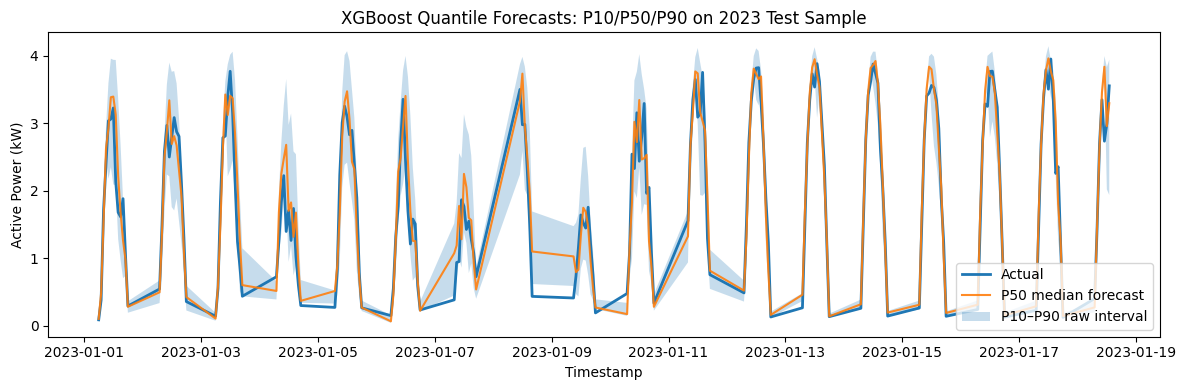

In [36]:
#Plot corrected quantile interval on a 2023 test sample

plot_quantile_sample = test_quantile_table[
    test_quantile_table["timestamp"] >= "2023-01-01"
].head(200)

plt.figure(figsize=(12, 4))

plt.plot(
    plot_quantile_sample["timestamp"],
    plot_quantile_sample["actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plot_quantile_sample["timestamp"],
    plot_quantile_sample["p50"],
    label="P50 median forecast",
    alpha=0.9
)

plt.fill_between(
    plot_quantile_sample["timestamp"],
    plot_quantile_sample["p10"],
    plot_quantile_sample["p90"],
    alpha=0.25,
    label="P10–P90 raw interval"
)

plt.title("XGBoost Quantile Forecasts: P10/P50/P90 on 2023 Test Sample")
plt.xlabel("Timestamp")
plt.ylabel("Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "xgboost_quantile_test_2023_sample.png", dpi=150)
plt.show()

In [37]:
#Save corrected quantile prediction tables

quantile_results_dir = RESULTS_DIR / "xgboost_quantile"
quantile_results_dir.mkdir(parents=True, exist_ok=True)

for split_name, table in quantile_tables.items():
    output_path = quantile_results_dir / f"{split_name}_quantile_predictions_raw_and_corrected.csv"
    table.to_csv(output_path, index=False)
    print("Saved:", output_path)

Saved: e:\D\Research Work FAST Thesis\pv-thesis\results\xgboost_quantile\train_quantile_predictions_raw_and_corrected.csv
Saved: e:\D\Research Work FAST Thesis\pv-thesis\results\xgboost_quantile\validation_quantile_predictions_raw_and_corrected.csv
Saved: e:\D\Research Work FAST Thesis\pv-thesis\results\xgboost_quantile\calibration_quantile_predictions_raw_and_corrected.csv
Saved: e:\D\Research Work FAST Thesis\pv-thesis\results\xgboost_quantile\test_quantile_predictions_raw_and_corrected.csv


In [42]:
required_corrected_cols = ["p10", "p50", "p90"]

if "test_quantile_table" not in globals():
    print("test_quantile_table does not exist yet. The correction cells may not have been run.")
else:
    print("test_quantile_table exists.")
    print("Columns:", test_quantile_table.columns.tolist())

    missing_corrected = [c for c in required_corrected_cols if c not in test_quantile_table.columns]

    if missing_corrected:
        print("Corrected quantile columns are missing:", missing_corrected)
        print("You are probably still looking only at raw quantiles.")
    else:
        fixed_cross_p10_p50 = test_quantile_table["p10"] > test_quantile_table["p50"]
        fixed_cross_p50_p90 = test_quantile_table["p50"] > test_quantile_table["p90"]
        fixed_cross_p10_p90 = test_quantile_table["p10"] > test_quantile_table["p90"]

        print("Corrected p10 > p50 rows:", int(fixed_cross_p10_p50.sum()))
        print("Corrected p50 > p90 rows:", int(fixed_cross_p50_p90.sum()))
        print("Corrected p10 > p90 rows:", int(fixed_cross_p10_p90.sum()))

test_quantile_table exists.
Columns: ['timestamp', 'actual', 'p10_raw', 'p50_raw', 'p90_raw', 'p10', 'p50', 'p90']
Corrected p10 > p50 rows: 0
Corrected p50 > p90 rows: 0
Corrected p10 > p90 rows: 0


### 06 — Raw quantile interval evaluation

This stage evaluates the corrected raw XGBoost quantile forecasts.

The corrected P10 and P90 forecasts form an 80% prediction interval.
The corrected P50 forecast is evaluated as the median point forecast.

Metrics:
- MAE/RMSE for P50 point accuracy
- PICP for empirical interval coverage
- PINAW for normalized interval width

In [44]:
#Final crossing check for all splits

def final_crossing_check(table, split_name):
    crossing = (
        (table["p10"] > table["p50"]) |
        (table["p50"] > table["p90"]) |
        (table["p10"] > table["p90"])
    )

    return {
        "split": split_name,
        "rows": len(table),
        "corrected_crossing_rows": int(crossing.sum()),
        "corrected_crossing_pct": round(crossing.mean() * 100, 3)
    }


final_crossing_summary = pd.DataFrame([
    final_crossing_check(table, split_name)
    for split_name, table in quantile_tables.items()
])

display(final_crossing_summary)

,split,rows,corrected_crossing_rows,corrected_crossing_pct
0,train,40978,0,0.0
1,validation,3869,0,0.0
2,calibration,3798,0,0.0
3,test,6506,0,0.0


In [45]:
#Define interval metric helper

RATED_CAPACITY_KW = 5.25
TARGET_INTERVAL_COVERAGE = 0.80


def quantile_interval_metrics(table, split_name, model_name="xgboost_quantile_raw"):
    y_true = table["actual"]
    p10 = table["p10"]
    p50 = table["p50"]
    p90 = table["p90"]

    interval_width = p90 - p10

    covered = (y_true >= p10) & (y_true <= p90)

    mae = mean_absolute_error(y_true, p50)
    rmse = np.sqrt(mean_squared_error(y_true, p50))

    picp = covered.mean()
    mean_width_kw = interval_width.mean()
    pinaw = mean_width_kw / RATED_CAPACITY_KW

    return {
        "model": model_name,
        "split": split_name,
        "rows": len(table),
        "P50_MAE_kW": round(mae, 4),
        "P50_RMSE_kW": round(rmse, 4),
        "PICP": round(picp, 4),
        "PICP_pct": round(picp * 100, 2),
        "target_coverage_pct": round(TARGET_INTERVAL_COVERAGE * 100, 1),
        "coverage_error_pct": round((picp - TARGET_INTERVAL_COVERAGE) * 100, 2),
        "mean_interval_width_kW": round(mean_width_kw, 4),
        "PINAW": round(pinaw, 4),
        "PINAW_pct_capacity": round(pinaw * 100, 2)
    }

In [46]:
#Evaluate raw corrected quantile intervals

#This is the key result table before conformal calibration.

raw_quantile_interval_metrics = pd.DataFrame([
    quantile_interval_metrics(table, split_name)
    for split_name, table in quantile_tables.items()
])

display(raw_quantile_interval_metrics)

,model,split,rows,P50_MAE_kW,P50_RMSE_kW,PICP,PICP_pct,target_coverage_pct,coverage_error_pct,mean_interval_width_kW,PINAW,PINAW_pct_capacity
0,xgboost_quantile_raw,train,40978,0.1703,0.3170,0.8061,80.61,80.0,0.61,0.5621,0.1071,10.71
1,xgboost_quantile_raw,validation,3869,0.1422,0.2746,0.8359,83.59,80.0,3.59,0.5372,0.1023,10.23
2,xgboost_quantile_raw,calibration,3798,0.1594,0.2936,0.7712,77.12,80.0,-2.88,0.5163,0.0983,9.83
3,xgboost_quantile_raw,test,6506,0.1736,0.3021,0.7860,78.60,80.0,-1.40,0.5981,0.1139,11.39


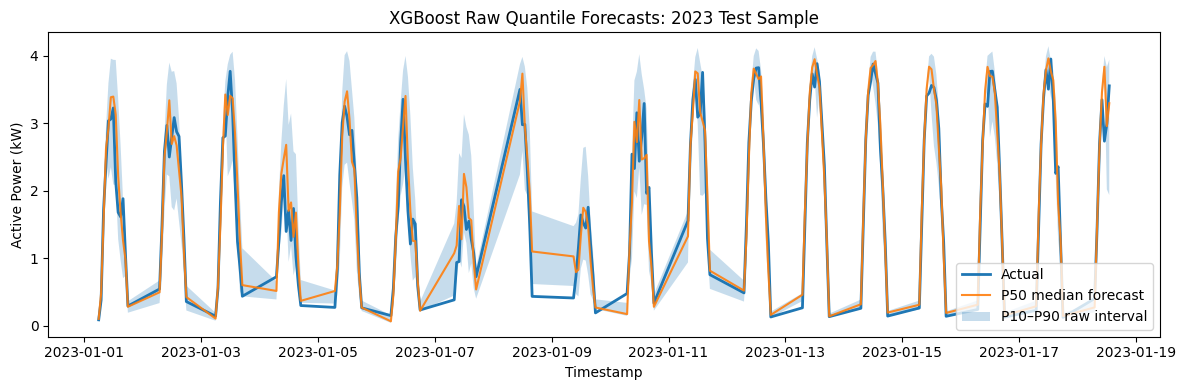

In [47]:
#Plot corrected quantile interval on 2023 test sample

plot_quantile_sample = test_quantile_table[
    test_quantile_table["timestamp"] >= "2023-01-01"
].head(200)

plt.figure(figsize=(12, 4))

plt.plot(
    plot_quantile_sample["timestamp"],
    plot_quantile_sample["actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plot_quantile_sample["timestamp"],
    plot_quantile_sample["p50"],
    label="P50 median forecast",
    alpha=0.9
)

plt.fill_between(
    plot_quantile_sample["timestamp"],
    plot_quantile_sample["p10"],
    plot_quantile_sample["p90"],
    alpha=0.25,
    label="P10–P90 raw interval"
)

plt.title("XGBoost Raw Quantile Forecasts: 2023 Test Sample")
plt.xlabel("Timestamp")
plt.ylabel("Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "xgboost_raw_quantile_interval_2023_test_sample.png", dpi=150)
plt.show()

Inference from above results: Raw quantile intervals are useful, but not perfectly calibrated. The raw XGBoost quantile model produces a reasonably sharp 80% prediction interval, but it slightly under-covers on the calibration and test sets. This motivates conformal calibration as a post-processing step.

In [48]:
#Save raw quantile metrics

raw_quantile_metrics_path = quantile_results_dir / "raw_quantile_interval_metrics.csv"

raw_quantile_interval_metrics.to_csv(raw_quantile_metrics_path, index=False)

print("Saved raw quantile interval metrics to:")
print(raw_quantile_metrics_path)

Saved raw quantile interval metrics to:
e:\D\Research Work FAST Thesis\pv-thesis\results\xgboost_quantile\raw_quantile_interval_metrics.csv


### 07 — Conformal calibration of XGBoost quantile intervals

The raw P10–P90 interval is slightly under-covering.

This stage applies split conformal calibration using the calibration set.
The conformal correction is computed only on the calibration split and then applied to the test split.

No model is retrained in this stage.

In [49]:
#Compute conformal correction from calibration set

ALPHA = 0.20  # 80% prediction interval
TARGET_COVERAGE = 1 - ALPHA

cal_table = quantile_tables["calibration"].copy()

# Conformal score for each calibration row:
# positive score means actual value was outside the raw interval.
# negative score means actual value was safely inside the interval.
cal_scores = np.maximum(
    cal_table["p10"] - cal_table["actual"],
    cal_table["actual"] - cal_table["p90"]
)

n_cal = len(cal_scores)

# Finite-sample conformal quantile level
q_level = np.ceil((n_cal + 1) * TARGET_COVERAGE) / n_cal
q_level = min(q_level, 1.0)

q_hat = np.quantile(cal_scores, q_level, method="higher")

cal_score_summary = pd.DataFrame([{
    "n_calibration_rows": n_cal,
    "target_coverage": TARGET_COVERAGE,
    "q_level_used": q_level,
    "conformal_correction_q_hat_kW": q_hat,
    "raw_calibration_picp": raw_quantile_interval_metrics.loc[
        raw_quantile_interval_metrics["split"] == "calibration",
        "PICP"
    ].iloc[0],
}])

display(cal_score_summary)

,n_calibration_rows,target_coverage,q_level_used,conformal_correction_q_hat_kW,raw_calibration_picp
0,3798,0.8,0.800421,0.006393,0.7712


In [50]:
#Apply conformal correction to all quantile tables

conformal_tables = {}

for split_name, table in quantile_tables.items():
    temp = table.copy()

    temp["p10_conformal"] = np.clip(
        temp["p10"] - q_hat,
        0,
        RATED_CAPACITY_KW
    )

    temp["p90_conformal"] = np.clip(
        temp["p90"] + q_hat,
        0,
        RATED_CAPACITY_KW
    )

    temp["p50_conformal"] = temp["p50"]

    conformal_tables[split_name] = temp

print("Conformal correction applied.")
print("q_hat:", round(q_hat, 5), "kW")

display(conformal_tables["test"].head())

Conformal correction applied.
q_hat: 0.00639 kW


,timestamp,actual,p10_raw,p50_raw,p90_raw,p10,p50,p90,p10_conformal,p90_conformal,p50_conformal
48645,2022-01-01 06:00:00,0.050464,0.084264,0.140547,0.172138,0.084264,0.140547,0.172138,0.077871,0.178531,0.140547
48646,2022-01-01 07:00:00,0.334097,0.435753,0.500605,0.552183,0.435753,0.500605,0.552183,0.429360,0.558576,0.500605
48647,2022-01-01 08:00:00,1.733606,1.636702,1.748029,1.838541,1.636702,1.748029,1.838541,1.630309,1.844934,1.748029
48648,2022-01-01 09:00:00,2.756478,2.698221,2.780206,2.924938,2.698221,2.780206,2.924938,2.691829,2.931331,2.780206
48649,2022-01-01 10:00:00,3.342267,3.387340,3.461565,3.560797,3.387340,3.461565,3.560797,3.380947,3.567190,3.461565


In [51]:
#Evaluate conformal intervals

def conformal_interval_metrics(table, split_name, model_name="xgboost_quantile_conformal"):
    y_true = table["actual"]
    p50 = table["p50_conformal"]
    lower = table["p10_conformal"]
    upper = table["p90_conformal"]

    interval_width = upper - lower
    covered = (y_true >= lower) & (y_true <= upper)

    mae = mean_absolute_error(y_true, p50)
    rmse = np.sqrt(mean_squared_error(y_true, p50))

    picp = covered.mean()
    mean_width_kw = interval_width.mean()
    pinaw = mean_width_kw / RATED_CAPACITY_KW

    return {
        "model": model_name,
        "split": split_name,
        "rows": len(table),
        "P50_MAE_kW": round(mae, 4),
        "P50_RMSE_kW": round(rmse, 4),
        "PICP": round(picp, 4),
        "PICP_pct": round(picp * 100, 2),
        "target_coverage_pct": round(TARGET_COVERAGE * 100, 1),
        "coverage_error_pct": round((picp - TARGET_COVERAGE) * 100, 2),
        "mean_interval_width_kW": round(mean_width_kw, 4),
        "PINAW": round(pinaw, 4),
        "PINAW_pct_capacity": round(pinaw * 100, 2)
    }


conformal_interval_metrics_df = pd.DataFrame([
    conformal_interval_metrics(table, split_name)
    for split_name, table in conformal_tables.items()
])

display(conformal_interval_metrics_df)

,model,split,rows,P50_MAE_kW,P50_RMSE_kW,PICP,PICP_pct,target_coverage_pct,coverage_error_pct,mean_interval_width_kW,PINAW,PINAW_pct_capacity
0,xgboost_quantile_conformal,train,40978,0.1703,0.3170,0.8366,83.66,80.0,3.66,0.5749,0.1095,10.95
1,xgboost_quantile_conformal,validation,3869,0.1422,0.2746,0.8599,85.99,80.0,5.99,0.5500,0.1048,10.48
2,xgboost_quantile_conformal,calibration,3798,0.1594,0.2936,0.8007,80.07,80.0,0.07,0.5291,0.1008,10.08
3,xgboost_quantile_conformal,test,6506,0.1736,0.3021,0.8077,80.77,80.0,0.77,0.6109,0.1164,11.64


In [52]:
#Compare raw vs conformal on test set

raw_test_metrics = raw_quantile_interval_metrics[
    raw_quantile_interval_metrics["split"] == "test"
].copy()

conformal_test_metrics = conformal_interval_metrics_df[
    conformal_interval_metrics_df["split"] == "test"
].copy()

raw_vs_conformal_test = pd.concat(
    [raw_test_metrics, conformal_test_metrics],
    ignore_index=True
)

display(raw_vs_conformal_test)

,model,split,rows,P50_MAE_kW,P50_RMSE_kW,PICP,PICP_pct,target_coverage_pct,coverage_error_pct,mean_interval_width_kW,PINAW,PINAW_pct_capacity
0,xgboost_quantile_raw,test,6506,0.1736,0.3021,0.7860,78.60,80.0,-1.40,0.5981,0.1139,11.39
1,xgboost_quantile_conformal,test,6506,0.1736,0.3021,0.8077,80.77,80.0,0.77,0.6109,0.1164,11.64


### 08 — Raw vs conformal interval comparison

This section summarizes the effect of conformal calibration on the XGBoost quantile interval.

The goal is to compare:
- raw P10–P90 interval
- conformalized P10–P90 interval

on coverage and interval width.

In [53]:
#Create final comparison table

raw_metrics_labeled = raw_quantile_interval_metrics.copy()
raw_metrics_labeled["interval_type"] = "raw_quantile"

conformal_metrics_labeled = conformal_interval_metrics_df.copy()
conformal_metrics_labeled["interval_type"] = "conformalized_quantile"

interval_comparison_all_splits = pd.concat(
    [raw_metrics_labeled, conformal_metrics_labeled],
    ignore_index=True
)

display(
    interval_comparison_all_splits
    .sort_values(["split", "interval_type"])
)

,model,split,rows,P50_MAE_kW,P50_RMSE_kW,PICP,PICP_pct,target_coverage_pct,coverage_error_pct,mean_interval_width_kW,PINAW,PINAW_pct_capacity,interval_type
6,xgboost_quantile_conformal,calibration,3798,0.1594,0.2936,0.8007,80.07,80.0,0.07,0.5291,0.1008,10.08,conformalized_quantile
2,xgboost_quantile_raw,calibration,3798,0.1594,0.2936,0.7712,77.12,80.0,-2.88,0.5163,0.0983,9.83,raw_quantile
7,xgboost_quantile_conformal,test,6506,0.1736,0.3021,0.8077,80.77,80.0,0.77,0.6109,0.1164,11.64,conformalized_quantile
3,xgboost_quantile_raw,test,6506,0.1736,0.3021,0.7860,78.60,80.0,-1.40,0.5981,0.1139,11.39,raw_quantile
4,xgboost_quantile_conformal,train,40978,0.1703,0.3170,0.8366,83.66,80.0,3.66,0.5749,0.1095,10.95,conformalized_quantile
0,xgboost_quantile_raw,train,40978,0.1703,0.3170,0.8061,80.61,80.0,0.61,0.5621,0.1071,10.71,raw_quantile
5,xgboost_quantile_conformal,validation,3869,0.1422,0.2746,0.8599,85.99,80.0,5.99,0.5500,0.1048,10.48,conformalized_quantile
1,xgboost_quantile_raw,validation,3869,0.1422,0.2746,0.8359,83.59,80.0,3.59,0.5372,0.1023,10.23,raw_quantile


In [54]:
#Create clean test comparison summary

raw_test = raw_quantile_interval_metrics[
    raw_quantile_interval_metrics["split"] == "test"
].iloc[0]

conformal_test = conformal_interval_metrics_df[
    conformal_interval_metrics_df["split"] == "test"
].iloc[0]

test_interval_improvement = pd.DataFrame([{
    "raw_PICP_pct": raw_test["PICP_pct"],
    "conformal_PICP_pct": conformal_test["PICP_pct"],
    "target_coverage_pct": conformal_test["target_coverage_pct"],
    "PICP_change_pct_points": round(conformal_test["PICP_pct"] - raw_test["PICP_pct"], 2),
    "raw_mean_width_kW": raw_test["mean_interval_width_kW"],
    "conformal_mean_width_kW": conformal_test["mean_interval_width_kW"],
    "width_increase_kW": round(conformal_test["mean_interval_width_kW"] - raw_test["mean_interval_width_kW"], 4),
    "raw_PINAW_pct_capacity": raw_test["PINAW_pct_capacity"],
    "conformal_PINAW_pct_capacity": conformal_test["PINAW_pct_capacity"]
}])

display(test_interval_improvement)

,raw_PICP_pct,conformal_PICP_pct,target_coverage_pct,PICP_change_pct_points,raw_mean_width_kW,conformal_mean_width_kW,width_increase_kW,raw_PINAW_pct_capacity,conformal_PINAW_pct_capacity
0,78.6,80.77,80.0,2.17,0.5981,0.6109,0.0128,11.39,11.64


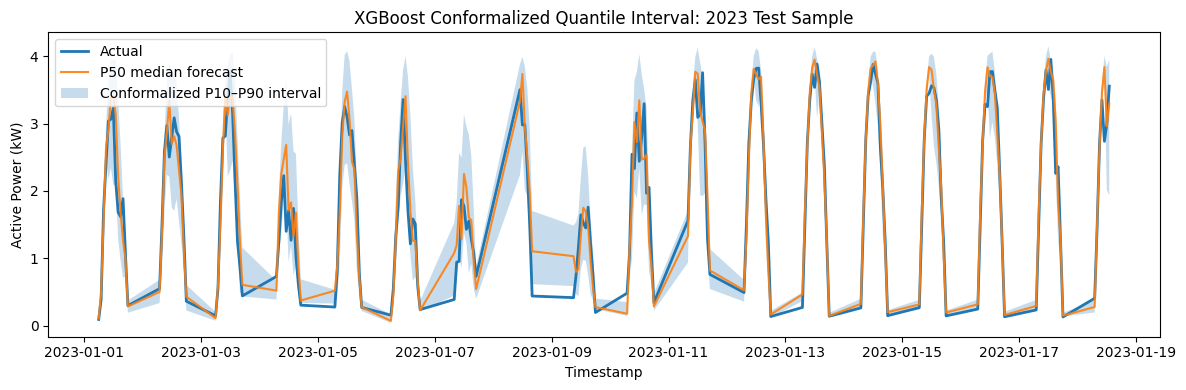

In [55]:
#Plot conformalized interval on 2023 test sample

test_conformal_table = conformal_tables["test"].copy()

plot_conformal_sample = test_conformal_table[
    test_conformal_table["timestamp"] >= "2023-01-01"
].head(200)

plt.figure(figsize=(12, 4))

plt.plot(
    plot_conformal_sample["timestamp"],
    plot_conformal_sample["actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    plot_conformal_sample["timestamp"],
    plot_conformal_sample["p50_conformal"],
    label="P50 median forecast",
    alpha=0.9
)

plt.fill_between(
    plot_conformal_sample["timestamp"],
    plot_conformal_sample["p10_conformal"],
    plot_conformal_sample["p90_conformal"],
    alpha=0.25,
    label="Conformalized P10–P90 interval"
)

plt.title("XGBoost Conformalized Quantile Interval: 2023 Test Sample")
plt.xlabel("Timestamp")
plt.ylabel("Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "xgboost_conformalized_quantile_interval_2023_test_sample.png", dpi=150)
plt.show()

In [56]:
#Save conformal results

conformal_results_dir = RESULTS_DIR / "xgboost_conformal"
conformal_results_dir.mkdir(parents=True, exist_ok=True)

interval_comparison_all_splits.to_csv(
    conformal_results_dir / "raw_vs_conformal_interval_metrics_all_splits.csv",
    index=False
)

test_interval_improvement.to_csv(
    conformal_results_dir / "test_interval_improvement_summary.csv",
    index=False
)

for split_name, table in conformal_tables.items():
    table.to_csv(
        conformal_results_dir / f"{split_name}_conformal_predictions.csv",
        index=False
    )

print("Saved conformal comparison results to:")
print(conformal_results_dir)

Saved conformal comparison results to:
e:\D\Research Work FAST Thesis\pv-thesis\results\xgboost_conformal


Conclusion: Conformal calibration improved test coverage from 78.60% to 80.77%, reaching the target 80% coverage with only a small interval-width increase of 0.0128 kW.

### 09 — Save final ML artifacts

This section saves the trained XGBoost models, final summary table, and conformal calibration configuration so that the pipeline can be reloaded later without retraining.

In [57]:
#Save trained models

models_dir = ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)

xgb_point_model.save_model(models_dir / "xgb_point_model.json")

for name, model in xgb_quantile_models.items():
    model.save_model(models_dir / f"xgb_quantile_{name}.json")

print("Saved trained XGBoost models to:")
print(models_dir)

Saved trained XGBoost models to:
e:\D\Research Work FAST Thesis\pv-thesis\models


In [58]:
#Save final compact summary

final_results_dir = RESULTS_DIR / "final_ml_pipeline_v1"
final_results_dir.mkdir(parents=True, exist_ok=True)

final_summary = pd.DataFrame([{
    "point_model_test_MAE_kW": xgb_point_metrics.loc[
        xgb_point_metrics["split"] == "test", "MAE_kW"
    ].iloc[0],
    "point_model_test_RMSE_kW": xgb_point_metrics.loc[
        xgb_point_metrics["split"] == "test", "RMSE_kW"
    ].iloc[0],
    "raw_quantile_test_PICP_pct": test_interval_improvement["raw_PICP_pct"].iloc[0],
    "conformal_test_PICP_pct": test_interval_improvement["conformal_PICP_pct"].iloc[0],
    "target_coverage_pct": test_interval_improvement["target_coverage_pct"].iloc[0],
    "raw_mean_width_kW": test_interval_improvement["raw_mean_width_kW"].iloc[0],
    "conformal_mean_width_kW": test_interval_improvement["conformal_mean_width_kW"].iloc[0],
    "width_increase_kW": test_interval_improvement["width_increase_kW"].iloc[0],
    "conformal_q_hat_kW": q_hat
}])

final_summary.to_csv(final_results_dir / "final_summary.csv", index=False)

display(final_summary)

print("Saved final summary to:")
print(final_results_dir / "final_summary.csv")

,point_model_test_MAE_kW,point_model_test_RMSE_kW,raw_quantile_test_PICP_pct,conformal_test_PICP_pct,target_coverage_pct,raw_mean_width_kW,conformal_mean_width_kW,width_increase_kW,conformal_q_hat_kW
0,0.1781,0.2948,78.6,80.77,80.0,0.5981,0.6109,0.0128,0.006393


Saved final summary to:
e:\D\Research Work FAST Thesis\pv-thesis\results\final_ml_pipeline_v1\final_summary.csv


In [59]:
#Save conformal calibration config

conformal_config = pd.DataFrame([{
    "alpha": ALPHA,
    "target_coverage": TARGET_COVERAGE,
    "q_hat_kW": q_hat,
    "n_calibration_rows": len(quantile_tables["calibration"])
}])

conformal_config.to_csv(
    final_results_dir / "conformal_calibration_config.csv",
    index=False
)

display(conformal_config)

print("Saved conformal calibration config to:")
print(final_results_dir / "conformal_calibration_config.csv")

,alpha,target_coverage,q_hat_kW,n_calibration_rows
0,0.2,0.8,0.006393,3798


Saved conformal calibration config to:
e:\D\Research Work FAST Thesis\pv-thesis\results\final_ml_pipeline_v1\conformal_calibration_config.csv
